In [3]:
import pandas as pd
import numpy as np
sales = pd.read_csv(r"C:\Users\chara\OneDrive - Manipal Academy of Higher Education\Sales Forecasting\Sample - Superstore.csv",encoding="latin1")
print(sales.head())
#print(sales.info())
#print(sales.describe())
print(sales.columns)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [4]:
#print(sales.isnull().sum)
print(sales.isnull().values.any())

False


In [5]:
sales = sales.drop_duplicates()
print("Duplicate rows:",sales.duplicated().sum())

Duplicate rows: 0


In [6]:
sales['Order Date'] = pd.to_datetime(sales['Order Date'])

In [32]:
sales['Year'] = sales['Order Date'].dt.year
sales['Month'] = sales['Order Date'].dt.month
sales['Day'] = sales['Order Date'].dt.day
sales['DayOfWeek'] = sales['Order Date'].dt.dayofweek
sales['Quarter'] = sales['Order Date'].dt.quarter

In [33]:
Dategroup = sales.groupby('Order Date')['Sales'].sum()
Monthgroup = sales.groupby('Month')['Sales'].sum()
Regiongroup = sales.groupby('Region')['Sales'].sum()
print(Dategroup.head())
print(Monthgroup.head())
print(Countrygroup.head())

Order Date
2014-01-03      16.448
2014-01-04     288.060
2014-01-05      19.536
2014-01-06    4407.100
2014-01-07      87.158
Name: Sales, dtype: float64
Month
1     94924.8356
2     59751.2514
3    205005.4888
4    137762.1286
5    155028.8117
Name: Sales, dtype: float64
Country
United States    2.297201e+06
Name: Sales, dtype: float64


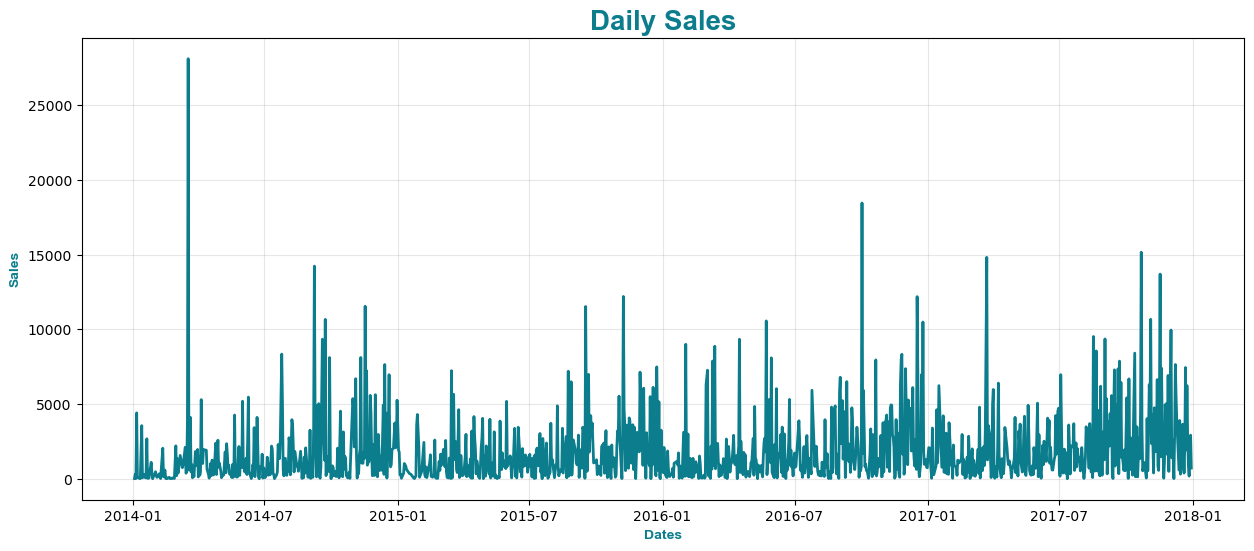

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.plot(Dategroup,linestyle="solid",linewidth=2,color="#0b7d8c")
plt.title("Daily Sales",fontsize =20,family="Arial",color="#0b7d8c",fontweight = "bold")
plt.xlabel("Dates",fontsize =10,family="Arial",color="#0b7d8c",fontweight = "bold")
plt.ylabel("Sales",fontsize =10,family="Arial",color="#0b7d8c",fontweight = "bold")
plt.grid(alpha=0.3)
plt.show()

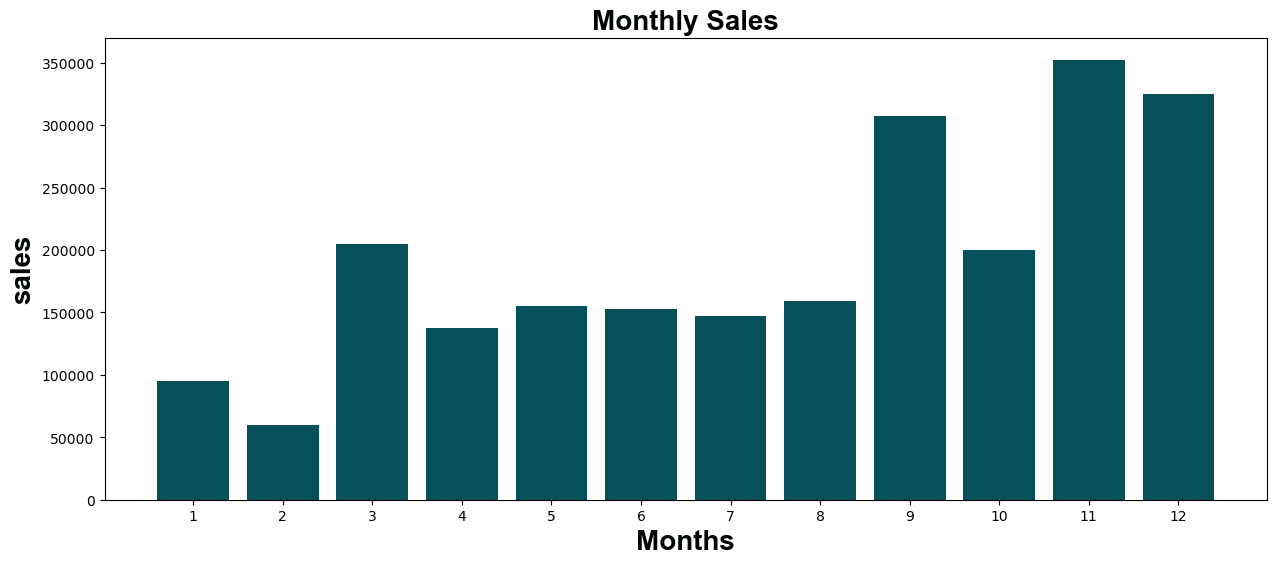

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.bar(Monthgroup.index.astype(str),Monthgroup.values,color = "#06505c")
plt.title("Monthly Sales",fontsize=20,family="Arial",fontweight="bold",color="#000405")
plt.xlabel("Months",fontsize=20,family="Arial",fontweight="bold",color="#000405")
plt.ylabel("sales",fontsize=20,family="Arial",fontweight="bold",color="#000405")
plt.show()

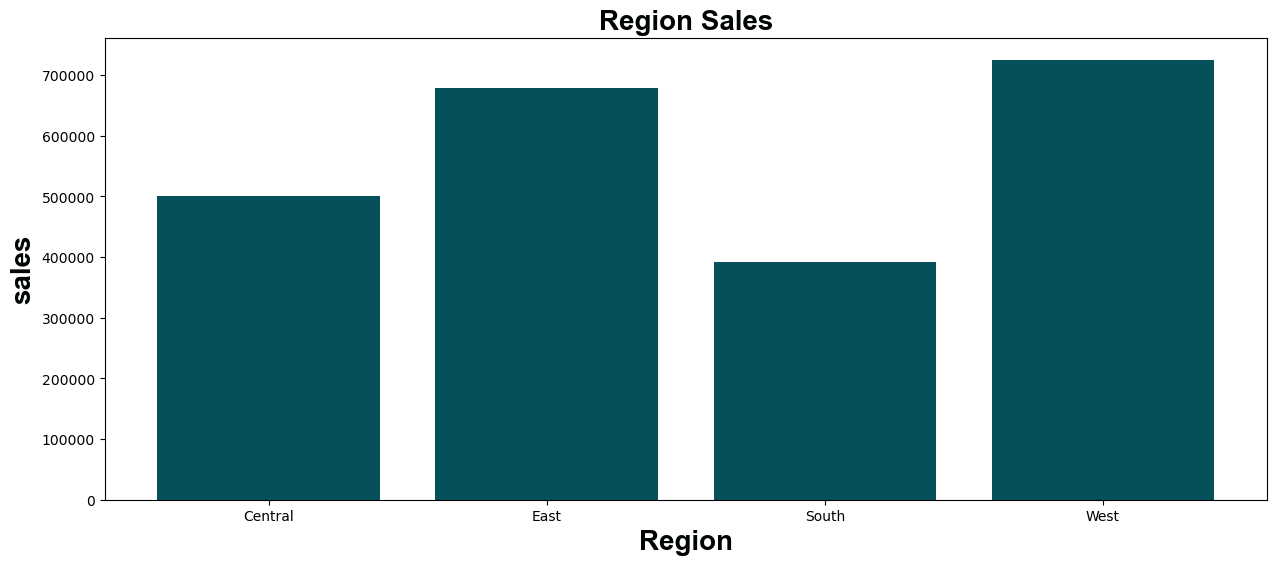

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.bar(Regiongroup.index.astype(str),Regiongroup.values,color = "#06505c")
plt.title("Region Sales",fontsize=20,family="Arial",fontweight="bold",color="#000405")
plt.xlabel("Region",fontsize=20,family="Arial",fontweight="bold",color="#000405")
plt.ylabel("sales",fontsize=20,family="Arial",fontweight="bold",color="#000405")
plt.show()

In [71]:
from sklearn.model_selection import train_test_split
x = sales[['Quantity','Discount','Profit','Month','Quarter']]
y = sales['Sales']
print(x.columns)

Index(['Quantity', 'Discount', 'Profit', 'Month', 'Quarter'], dtype='object')


In [72]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.columns)

Index(['Quantity', 'Discount', 'Profit', 'Month', 'Quarter'], dtype='object')


In [73]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(7995, 5)
(1999, 5)
(7995,)
(1999,)


In [74]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
reg.fit(x_train,y_train)
y_pred = reg.predict(x_test)
print(y_pred)

[226.84953623 135.94215721  96.08106775 ... 170.03444413 256.60948629
 -17.70397504]


In [75]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2:", r2_score(y_test,y_pred))

MAE: 245.02449391507912
MSE: 825.0351851605521
R2: -0.15233455473267687


Future Data:
        Date  Month  Quarter  Quantity  Discount     Profit
0 2017-12-31     12        4  3.789574  0.156203  28.656896
1 2018-01-01      1        1  3.789574  0.156203  28.656896
2 2018-01-02      1        1  3.789574  0.156203  28.656896
3 2018-01-03      1        1  3.789574  0.156203  28.656896
4 2018-01-04      1        1  3.789574  0.156203  28.656896

Forecasted Sales:
         Date  Predicted Sales
0  2017-12-31       226.142265
1  2018-01-01       217.649299
2  2018-01-02       217.649299
3  2018-01-03       217.649299
4  2018-01-04       217.649299
5  2018-01-05       217.649299
6  2018-01-06       217.649299
7  2018-01-07       217.649299
8  2018-01-08       217.649299
9  2018-01-09       217.649299
10 2018-01-10       217.649299
11 2018-01-11       217.649299
12 2018-01-12       217.649299
13 2018-01-13       217.649299
14 2018-01-14       217.649299
15 2018-01-15       217.649299
16 2018-01-16       217.649299
17 2018-01-17       217.649299
18 2018-01-18      

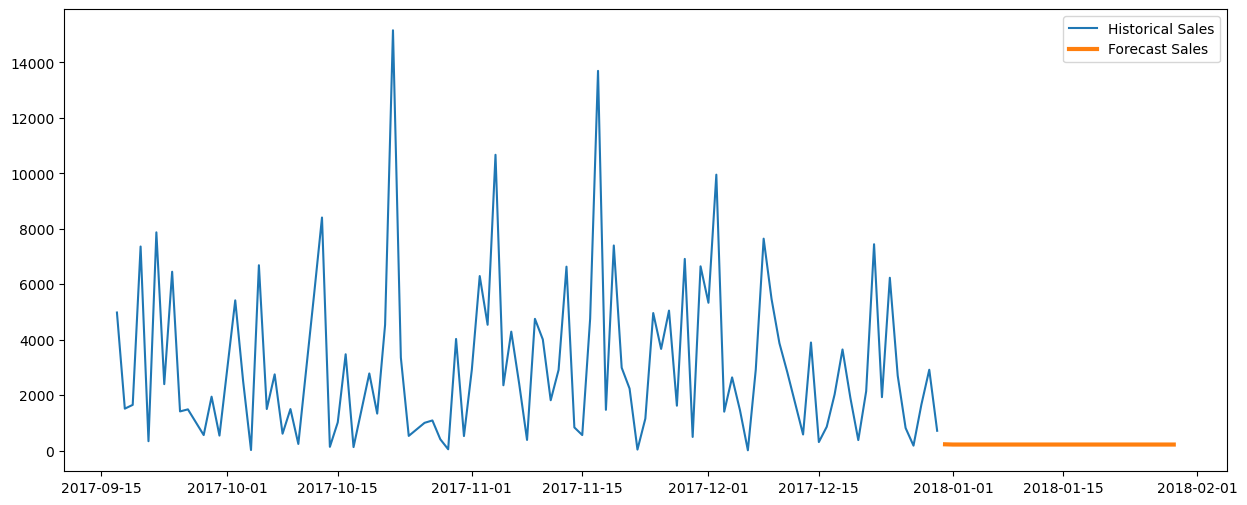

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
future_dates = pd.date_range(
    start=sales['Order Date'].max() + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)
future_data = pd.DataFrame()
future_data['Date'] = future_dates
future_data['Month'] = future_dates.month
future_data['Quarter'] = future_dates.quarter
future_data['Quantity'] = sales['Quantity'].mean()
future_data['Discount'] = sales['Discount'].mean()
future_data['Profit'] = sales['Profit'].mean()
print("Future Data:")
print(future_data.head())
future_X = future_data[
    ['Quantity', 'Discount', 'Profit', 'Month', 'Quarter']
]
future_sales = reg.predict(future_X)
future_data['Predicted Sales'] = future_sales
print("\nForecasted Sales:")
print(future_data[['Date', 'Predicted Sales']])
daily_sales = sales.groupby('Order Date')['Sales'].sum()
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales.index[-100:],
    daily_sales.values[-100:],
    label='Historical Sales'
)

plt.plot(
    future_data['Date'],
    future_data['Predicted Sales'],
    label='Forecast Sales',
    linewidth=3
)

plt.legend()
plt.show()